In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('smartcart_customers.csv')

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocessing

## 1. Handle Missing Values

In [6]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [7]:
df.head()
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## Feature Engineering

In [8]:
# Age
df['Age'] = 2026-df['Year_Birth']

In [9]:
# Customer Joining Date
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
reference_date = df['Dt_Customer'].max()
df['Customer_Tenure_Days'] = (reference_date - df['Dt_Customer']).dt.days

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [11]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [12]:
# Spending

df['Total_Spending']=df['MntWines']+df['MntFruits']+df['MntSweetProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']

In [13]:
# Children

df['Total_Children'] = df['Kidhome']+df['Teenhome']

In [14]:
# Education

df['Education'].value_counts()

df['Education'] = df['Education'].replace({
    'Basic':'Undergraduate','2n Cycle':'Undergraduate',
    'Graduation':'Graduate',
    'Master':'Postgraduate','PhD':'Postgraduate'
})

In [15]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [16]:
# Marital Status

df['Living_With'] = df['Marital_Status'].replace({
    'Married':'Partner','Together':'Partner',
    'Single':'Alone','Divorced':'Alone','Widow':'Alone',
    'Absurd':'Alone','YOLO':'Alone'
})

In [17]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1159,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,22,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,670,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,36,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,331,1,Partner


In [18]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

## Drop Columns

In [19]:
cols = ['ID','Year_Birth','Marital_Status','Kidhome','Teenhome','Dt_Customer']
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [20]:
df_cleaned.shape

(2240, 15)

In [21]:
df.shape

(2240, 27)

In [22]:
## Outliers

In [23]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'Total_Spending', 'Total_Children',
       'Living_With'],
      dtype='object')

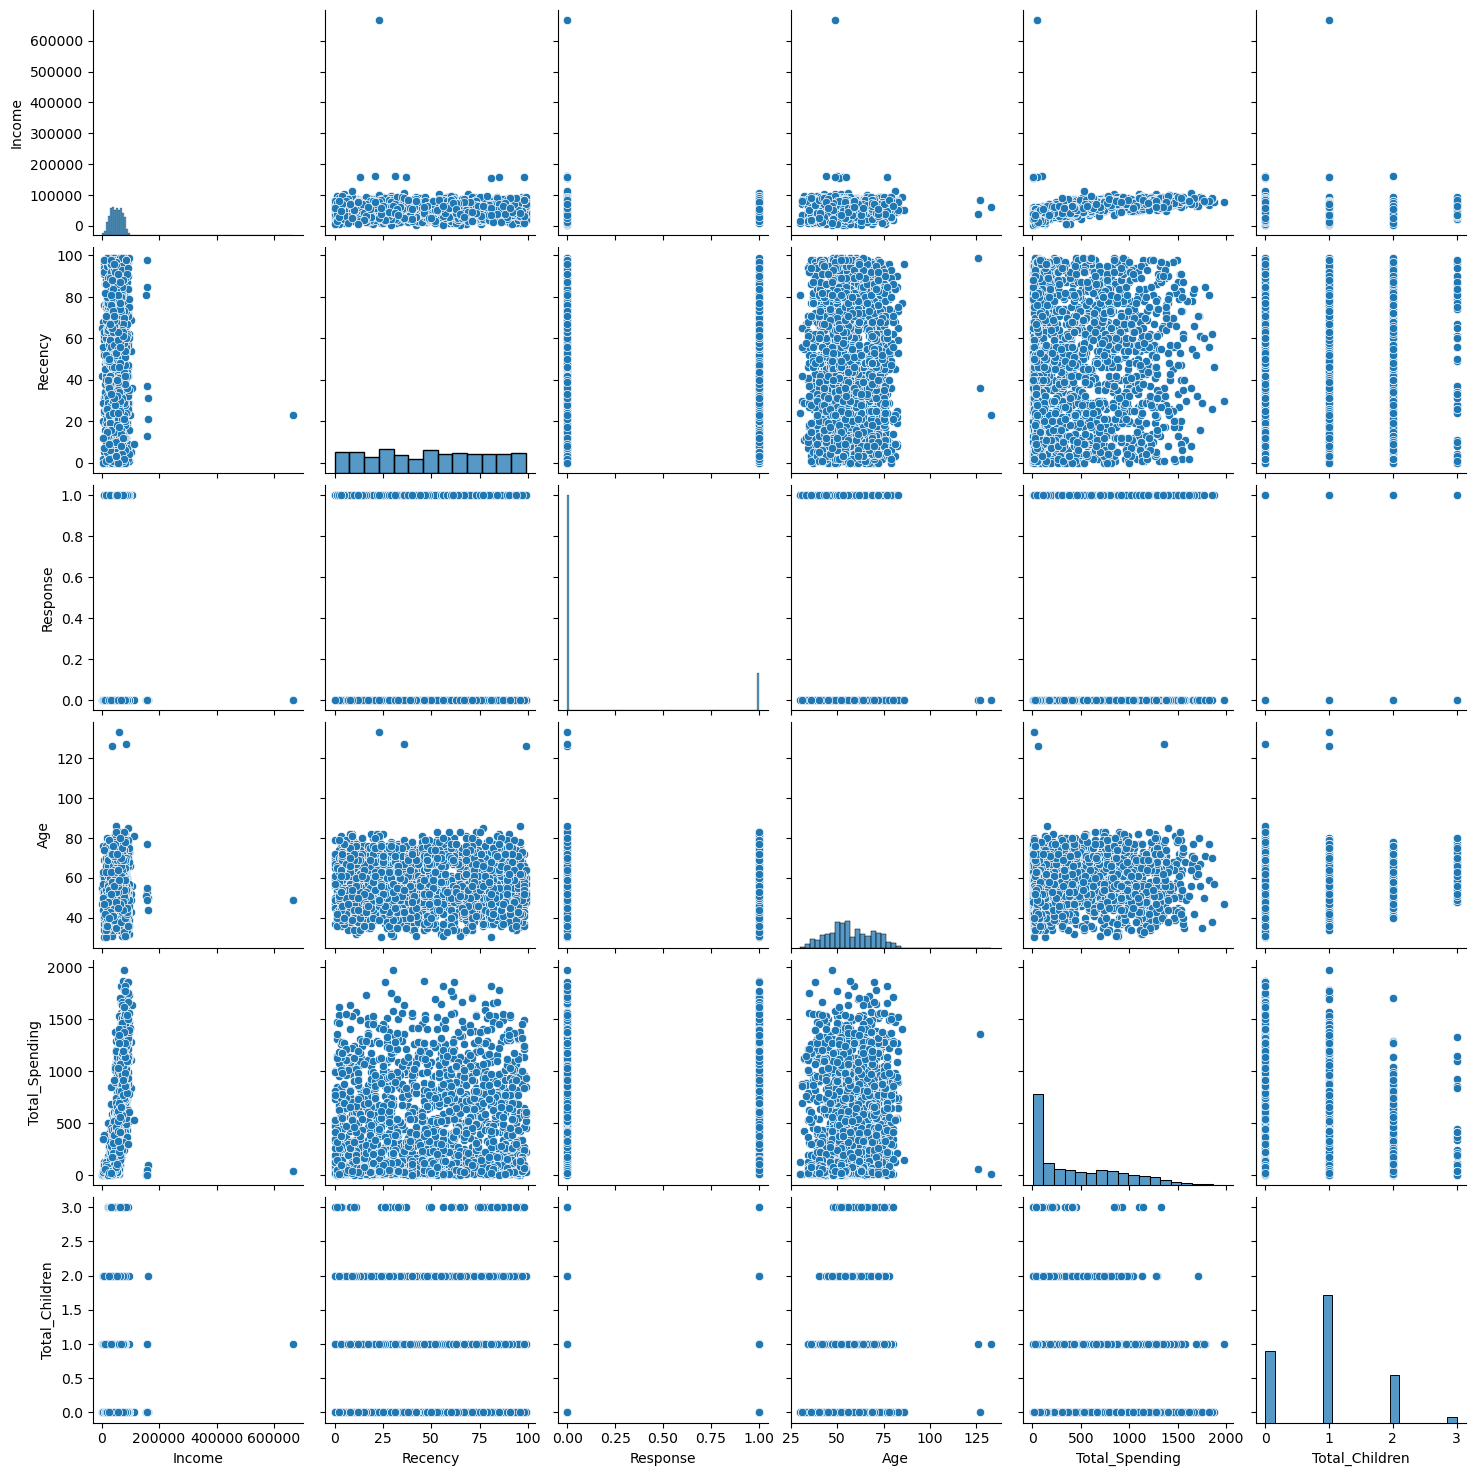

In [24]:
cols = ['Income','Recency','Response','Age','Total_Spending','Total_Children']

# relative plots of some features - pair plots

sns.pairplot(df_cleaned[cols])

In [25]:
# Remove Outliers

print('data size with outliers',len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned['Age']<90)]
df_cleaned = df_cleaned[(df_cleaned['Income']<600_000)]

print('data size with outliers',len(df_cleaned))

data size with outliers 2240
data size with outliers 2236


## Heatmap

In [26]:
corr = df_cleaned.corr(numeric_only = True)

<Axes: >

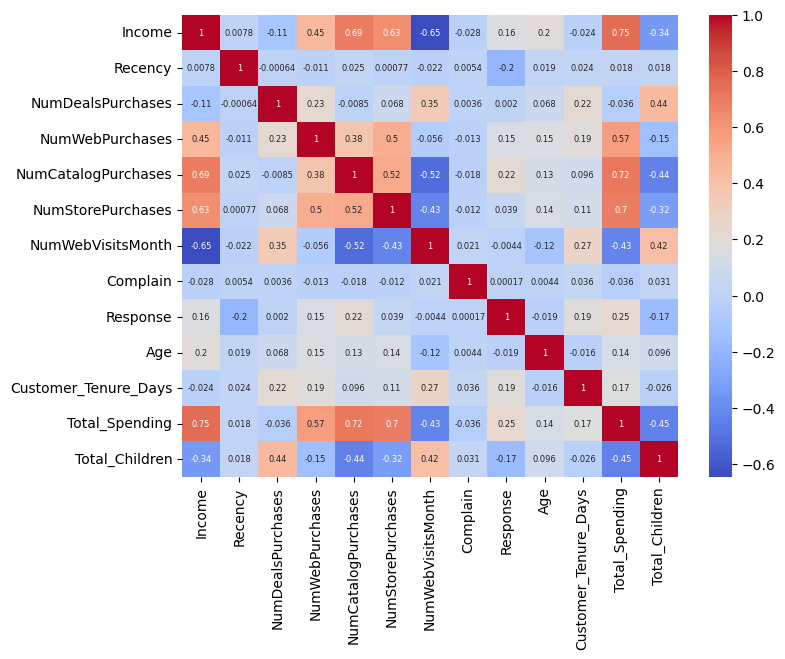

In [27]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot = True,
    annot_kws={'size':6},
    cmap='coolwarm'

)

In [28]:
from sklearn.preprocessing import OneHotEncoder

In [29]:
ohe = OneHotEncoder()

cat_cols = ['Education','Living_With']

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [30]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [31]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [32]:
df_encoded.shape

(2236, 18)

In [33]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1159,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,22,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,670,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,36,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,331,1,0.0,1.0,0.0,0.0,1.0


## Scaling

In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
X= df_encoded

In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [37]:
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

## Visualize

In [38]:
X_scaled.shape

(2236, 18)

In [39]:
from sklearn.decomposition import PCA

In [40]:
pca = PCA(n_components = 3)

X_pca = pca.fit_transform(X_scaled)

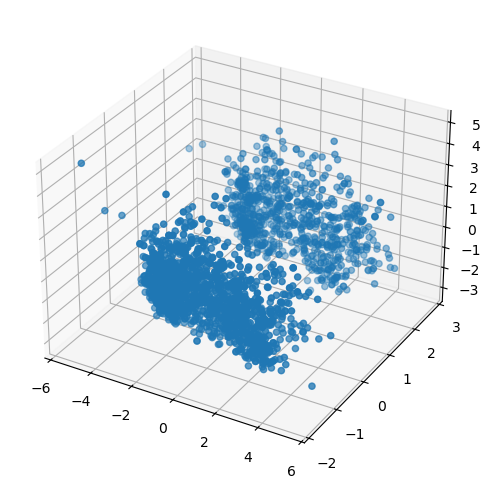

In [41]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection='3d')

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

## Analyze K value

### 1.Elbow Methd

In [42]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

C:\Users\OMEN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\OMEN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\OMEN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\OMEN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

In [43]:
knee = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
optimal_k = knee.elbow

In [44]:
print('best k =',optimal_k)

best k = 3


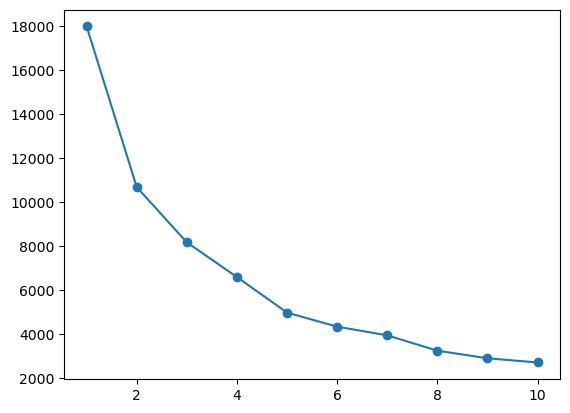

In [45]:
plt.plot(range(1,11),wcss,marker='o')

C:\Users\OMEN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\OMEN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\OMEN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\OMEN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

Text(0, 0.5, 'Silhouette Score')

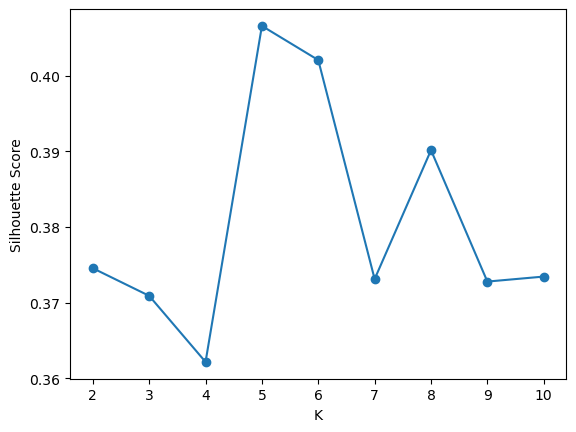

In [46]:
from sklearn.metrics import silhouette_score

scores =[]

for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

plt.plot(range(2,11),scores,marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')

Text(0, 0.5, 'SS')

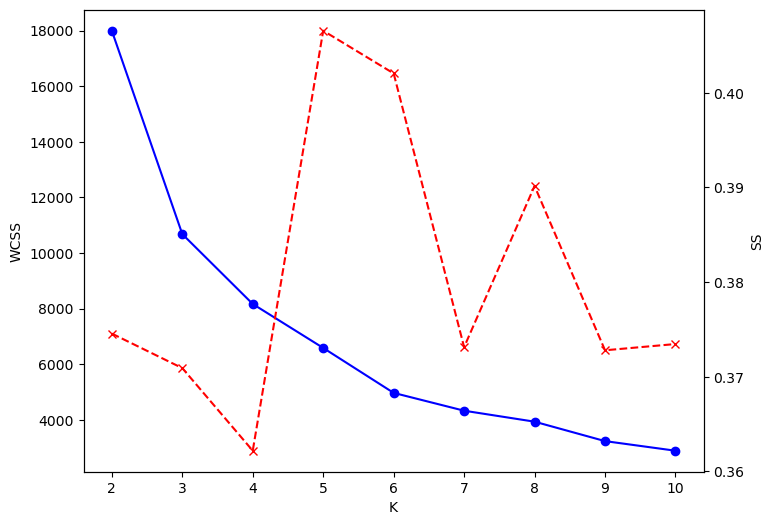

In [47]:
k_range = range(2,11)

fig,ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range,wcss[:len(k_range)],marker='o',color='blue')
ax1.set_xlabel('K')
ax1.set_ylabel('WCSS')

ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker='x',color='red',linestyle='--')
ax2.set_ylabel('SS')

In [48]:
# K_means
kmeans = KMeans(n_clusters=4,random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

C:\Users\OMEN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


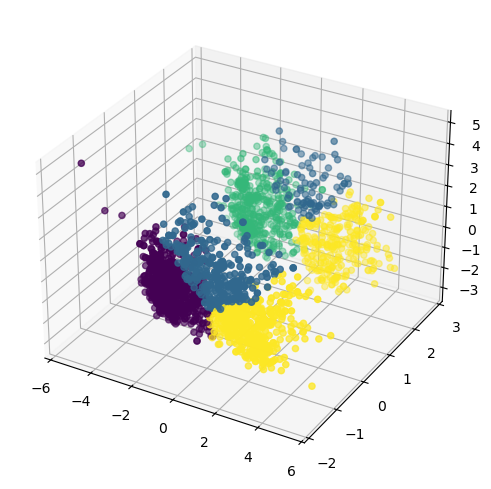

In [49]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection='3d')

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

In [50]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [51]:
agg_clf = AgglomerativeClustering(n_clusters=4,linkage='ward')
labels_agg = agg_clf.fit_predict(X_pca)

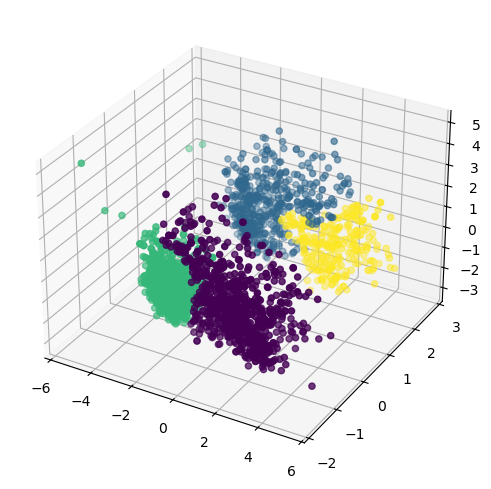

In [52]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection='3d')

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

## Characterization of Clusters

In [53]:
X['cluster'] = labels_agg

In [54]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1159,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,22,2,1.0,0.0,0.0,1.0,0.0,1
2,71613.0,26,1,8,2,10,4,0,0,61,312,670,0,1.0,0.0,0.0,0.0,1.0,0
3,26646.0,26,2,2,0,4,6,0,0,42,139,36,1,1.0,0.0,0.0,0.0,1.0,2
4,58293.0,94,5,5,3,6,5,0,0,45,161,331,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

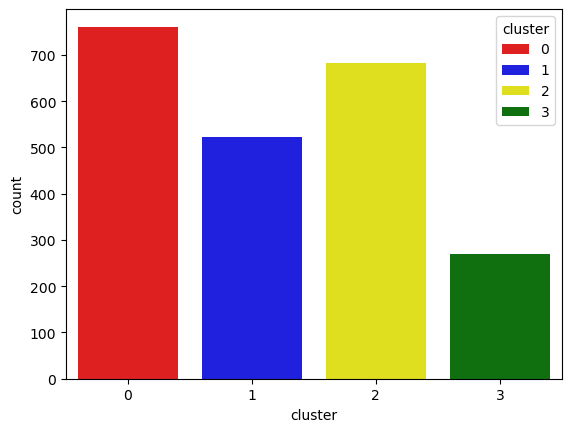

In [56]:
pal = ['red','blue','yellow','green']

sns.countplot(x=X['cluster'],palette=pal,hue=X['cluster'])

<Axes: xlabel='Total_Spending', ylabel='Income'>

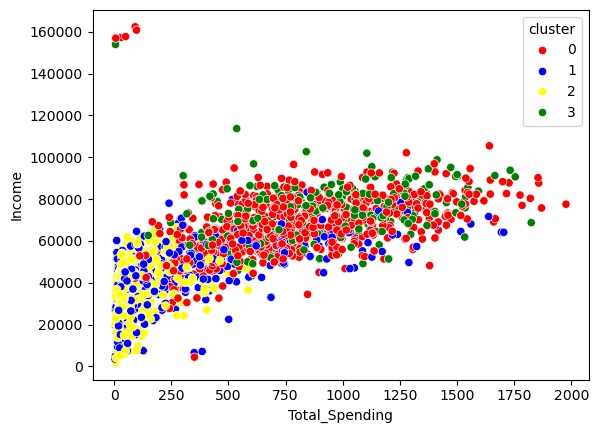

In [57]:
# Income & Spending patterns
sns.scatterplot(x=X['Total_Spending'],y=X['Income'],hue=X['cluster'],palette=pal)

In [58]:
# Cluster Summary

cluster_summary = X.groupby('cluster').mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        67277.602497  48.680683           2.488830         5.675427   
1        41047.619732  48.354406           2.605364         3.488506   
2        34580.737189  49.481698           2.263543         2.303075   
3        73786.253704  50.892593           1.485185         5.285185   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   4.521682           8.015769           4.176084  0.007884   
1                   1.390805           4.467433           6.356322  0.009579   
2                   0.546120           3.330893           6.647145  0.010249   
3                   5.240741           8.340741           3.174074  0.007407   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         